In [106]:
import pandas as pd
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer

In [107]:
first_df = pd.read_csv('analysis_data/first_data.csv')
second_df = pd.read_csv('analysis_data/second_data.csv')
third_df = pd.read_csv('analysis_data/third_data.csv')

# Pertanyaan Bisnis

- Skill apa yang memiliki bayaran tertinggi (top 10)?
- Bagaimana perbandingan pengalaman kerja dan median gaji di setiap ketagori pekerjaan?
- Apakah jumlah skill berbanding lurus dengan gaji?
- Apa skill yang paling dicari di dunia remote IT saat ini?
- Bagaimana pemetaan top 5 skill yang dibutuhkan pada setiap kategori pekerjaan?
- Berapa rata-rata jumlah skill yang menjadi syarat untuk masing-masing level pengalaman kerja?
- Bagaimana distribusi lowongan pekerjaan di setiap kategori pekerjaan?
- Level pengalaman apa yang paling dicari saat ini?

# EDA (Exploratory Data Analysis)

Cek kolom work_type. Bagaimana value yang ada pada tiap dataset, apakah sudah sama? 

In [108]:
display(first_df['formatted_work_type'].value_counts(dropna=False))

display(second_df['full_time_remote'].value_counts(dropna=False))

formatted_work_type
Full-time     11001
Contract       3165
Part-time       589
Internship      210
Volunteer       120
Temporary        85
Other            76
Name: count, dtype: int64

full_time_remote
Full-time · Mid-Senior level    1760
Full-time                        274
Internship                        92
Full-time · Associate             59
Contract                          40
Contract · Mid-Senior level       38
Part-time                         29
Full-time · Entry level           26
NaN                               15
Contract · Associate              14
Full-time · Director               8
Contract · Entry level             4
Temporary                          2
Internship · Internship            2
Full-time · Internship             2
Volunteer                          2
Full-time · Executive              1
Part-time · Mid-Senior level       1
Other · Associate                  1
Contract · Executive               1
Name: count, dtype: int64

Jika dilihat diatas, value dari work_type pada second_df berbeda dengan yang pertama. Namun bisa diekstrak agar sama dengan memisahkan string berdasarkan '-' dan ekstrak string yang sebelah kanan (ex: Full-time - Mid-Senior level, kita pisah dan ambil Mid-senior level saja)

In [109]:
second_df[['formatted_work_type', 'formatted_experience_level']] = (
    second_df['full_time_remote'].str.split(' · ', n=1, expand=True)
)
second_df.loc[second_df['formatted_work_type'] == 'Internship', 'formatted_experience_level'] = 'Internship'

In [110]:
display(first_df['formatted_work_type'].value_counts(dropna=False))
display(second_df['formatted_work_type'].value_counts(dropna=False))

formatted_work_type
Full-time     11001
Contract       3165
Part-time       589
Internship      210
Volunteer       120
Temporary        85
Other            76
Name: count, dtype: int64

formatted_work_type
Full-time     2130
Contract        97
Internship      94
Part-time       30
NaN             15
Temporary        2
Volunteer        2
Other            1
Name: count, dtype: int64

Cek kolom experience_level. Bagaimana value yang ada pada tiap dataset, apakah sudah sama? 

In [111]:
display(first_df['formatted_experience_level'].value_counts(dropna=False))

display(second_df['formatted_experience_level'].value_counts(dropna=False))

display(third_df['experience'].value_counts())

formatted_experience_level
Mid-Senior level    6377
NaN                 4757
Entry level         1947
Associate           1176
Director             670
Executive            229
Internship            90
Name: count, dtype: int64

formatted_experience_level
Mid-Senior level    1799
NaN                  362
Internship            96
Associate             74
Entry level           30
Director               8
Executive              2
Name: count, dtype: int64

experience
2.0     1511
3.0     1385
1.0     1330
5.0     1326
4.0     1251
6.0      146
7.0      137
8.0      131
0.0       90
9.0       87
10.0      50
12.0      15
11.0       9
1.5        9
3.5        5
0.6        3
14.0       2
13.0       2
15.0       1
4.5        1
2.5        1
Name: count, dtype: int64

In [112]:
first_df.dropna(subset=['formatted_experience_level'], inplace=True)

Disini kita extract dulu experience level untuk dataset kedua. agar experience levelnya sama seperti dataset pertama. Pada proses sebelumnya, kita sudah dapat experience level setelah memisah string berdasarkan -, san extract bagian kanan-nya (contract, part-time). Namun, ada beberapa yang tidak isi experience level, kita coba extract dari deskripsi dan judul

In [ ]:
# extract requirement pengalaman dalam tahun dari deskripsi
def extract_years(text):
    if pd.isna(text):
        return None
    
    patterns = [
        r'(\d+)\s*years?',                # 3 years
        r'(\d+)\s*\+\s*years?',           # 3+ years
        r'(\d+)\s*-\s*(\d+)\s*years?',    # 3-5 years
        r'(\d+)\s*to\s*(\d+)\s*years?',   # 3 to 5 years
        r'at least\s*(\d+)\s*years?',     # at least 3 years
        r'min\s*(\d+)\s*years?',          # min 3 years
        r'minimum\s*(\d+)\s*years?',      # minimum 3 years
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return int(match.group(1))
    
    return None

# dari hasil extract tahun pengalaman, kategorikan
def map_years_to_level(years):
    if years is None:
        return np.nan
    elif years <= 1:
        return 'Entry level'
    elif years <= 3:
        return 'Associate'
    elif years <= 7:
        return 'Mid-Senior level'
    else:
        return 'Director'

# coba extract tahun pengalaman dari title pekerjaan, contoh: sr. java developer
def extract_level_from_keywords(text):
    if pd.isna(text):
        return None
    
    # Order matters — check more specific first
    keyword_map = [
        (['executive', 'c-level', 'chief', 'ceo', 'cto', 'coo', 'president'],   'Executive'),
        (['director'],                                                             'Director'),
        (['senior', 'sr.', 'sr ', 'lead', 'principal', 'staff', 'manager'],      'Mid-Senior level'),
        (['mid', 'middle'],                                                        'Mid-Senior level'),
        (['junior', 'jr.', 'jr ', 'associate'],                                   'Associate'),
        (['entry', 'graduate', 'fresh', 'beginner', 'trainee'],                   'Entry level')
    ]
    
    text_lower = text.lower()
    for keywords, level in keyword_map:
        if any(kw in text_lower for kw in keywords):
            return level
    
    return None

# extract experience level menggunakan salah satu dari fungsi fungsi diatas
def resolve_experience_level(row):

    if not pd.isna(row['formatted_experience_level']):
        return row['formatted_experience_level']
    
    # Priority 1: cari keyword dari title
    level = extract_level_from_keywords(row.get('job_title'))
    if level:
        return level
    
    # Priority 2: cari angka tahun di deskripsi
    years = extract_years(row.get('job_details'))
    level = map_years_to_level(years)
    if not pd.isna(level):
        return level
    
    # Priority 3: cari keyword di deskripsi
    level = extract_level_from_keywords(row.get('job_details'))
    if level:
        return level
    
    # return Unspecified
    return "Other"

In [114]:
second_df.loc[second_df['formatted_work_type'] == 'Internship', 'formatted_experience_level'] = 'Internship'

null_mask = second_df['formatted_experience_level'].isna() & (second_df['formatted_work_type'] != 'Internship')
second_df.loc[null_mask, 'formatted_experience_level'] = second_df[null_mask].apply(resolve_experience_level, axis=1)

unmarked_experience_level = second_df[second_df['formatted_experience_level'].isna()]

second_df.rename(columns={"job_ID": "job_id", "job": "title"}, inplace=True)

Untuk dataset ketiga, kita mapping value tahun pada kolom experience menjadi experience_level yang serupa dengan dataset pertama dan dataset kedua

In [ ]:
def map_experience_to_level(years):
    if pd.isna(years):
        return "Other"
    elif years < 1.0:
        return "Internship"
    elif 1.0 <= years < 3.0:
        return "Entry level"
    elif 3.0 <= years < 5.0:
        return "Mid-Senior level"
    elif 5.0 <= years < 9.0:
        return "Associate"
    elif 9.0 <= years < 13.0:
        return "Executive"
    else:
        return "Director"

In [116]:
# Gaskan dataset ketiga kita mapping
third_df['formatted_experience_level'] = third_df['experience'].apply(map_experience_to_level)

In [117]:
display(first_df['formatted_experience_level'].value_counts(dropna=False))

display(second_df['formatted_experience_level'].value_counts(dropna=False))

display(third_df['formatted_experience_level'].value_counts(dropna=False))

formatted_experience_level
Mid-Senior level    6377
Entry level         1947
Associate           1176
Director             670
Executive            229
Internship            90
Name: count, dtype: int64

formatted_experience_level
Mid-Senior level    1945
Associate            138
Internship            96
Other                 59
Director              55
Entry level           50
Executive             28
Name: count, dtype: int64

formatted_experience_level
Entry level         2851
Mid-Senior level    2642
Associate           1740
Executive            161
Internship            93
Director               5
Name: count, dtype: int64

Cek kolom gaji pada dataset pertama. kolom normalized_salary adalah gaji yang sudah disamakan yaitu median gaji per tahun dari satu lowongan. Sekarang kita cek, apakah ada kolom yang punya min_salary, med_salary, atau max_salary tapi normalized_salary nya kosong

In [ ]:
salary_cols = ['min_salary', 'med_salary', 'max_salary']
anomaly_counts = 0
for col in salary_cols:
    has_salary = first_df[col].notna()
    null_normalized = first_df['normalized_salary'].isna()

    anomaly_counts = (has_salary & null_normalized).sum()

    print(f"Ada { anomaly_counts } baris dengan {col} terisi tapi normalized_salary kosong")

# if not anomaly_counts:
#     first_df.dropna(subset=['normalized_salary'], inplace=True)

Ada 0 baris dengan min_salary terisi tapi normalized_salary kosong
Ada 0 baris dengan med_salary terisi tapi normalized_salary kosong
Ada 0 baris dengan max_salary terisi tapi normalized_salary kosong


Sekarang, Kita coba cek outlier gaji pada dataset pertama dan dataset ketiga

In [119]:
def data_outlier(df, feature, remove=False):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    maximum = Q3 + (1.5*IQR)
    minimum = Q1 - (1.5*IQR)

    outliers = df[(df[feature] > maximum) | (df[feature] < minimum)]

    print(f"--- Outlier Inspection: '{feature}' ---")
    print(f"  IQR bounds  : [{minimum:.4f}, {maximum:.4f}]")
    print(f"  Outlier count: {len(outliers)} / {len(df)} rows ({100 * len(outliers) / len(df):.1f}%)")
    print(f"  Outlier range: [{outliers[feature].min():.4f}, {outliers[feature].max():.4f}]")
    print()

    if remove:
        df.loc[df[feature] > maximum, feature] = maximum
        df.loc[df[feature] < minimum, feature] = minimum
        return
    
    return outliers

In [120]:
first_outlier = data_outlier(first_df, 'normalized_salary')

third_outlier = data_outlier(third_df, 'med_salary')

--- Outlier Inspection: 'normalized_salary' ---
  IQR bounds  : [-30834.0625, 264723.4375]
  Outlier count: 92 / 10489 rows (0.9%)
  Outlier range: [265000.0000, 286000000.0000]

--- Outlier Inspection: 'med_salary' ---
  IQR bounds  : [-20500.0000, 123500.0000]
  Outlier count: 502 / 7492 rows (6.7%)
  Outlier range: [124000.0000, 1980000.0000]



Kita cek dulu, outlier in apakah memang valu extreme atau kelas minoritas? Mengingat jumlah dataset yang terbatas, kita tidak bisa menghapus dataset begitu saja

In [121]:
display(first_outlier[['title', 'pay_period', 'formatted_experience_level', 'min_salary', 'med_salary', 'max_salary', 'normalized_salary']].head(10))

display(third_outlier[['name', 'description', 'salary_range', 'med_salary', 'formatted_experience_level']].head(10))

,title,pay_period,formatted_experience_level,min_salary,med_salary,max_salary,normalized_salary
365,Vice President Finance,YEARLY,Director,260000.0,NaN,300000.0,280000.0
446,"Senior Medical Director, Clinical Development-...",YEARLY,Director,315000.0,NaN,350000.0,332500.0
478,Strategic Account Executive,YEARLY,Mid-Senior level,266000.0,NaN,350000.0,308000.0
676,Account Manager,YEARLY,Mid-Senior level,260000.0,NaN,300000.0,280000.0
751,Secret Shopper,HOURLY,Internship,NaN,600.0,NaN,1248000.0
1061,Senior Blockchain Engineer (Rust & Solana) - 1...,YEARLY,Mid-Senior level,150000.0,NaN,800000.0,475000.0
1135,Strategic Account Executive,YEARLY,Mid-Senior level,266000.0,NaN,350000.0,308000.0
1445,Senior Vice President of Retail Operations,YEARLY,Executive,450000.0,NaN,550000.0,500000.0
1761,Cloud Domain Architect,HOURLY,Mid-Senior level,125000.0,NaN,150000.0,286000000.0
1922,Founding Protocol Engineer,YEARLY,Mid-Senior level,250000.0,NaN,350000.0,300000.0


,name,description,salary_range,med_salary,formatted_experience_level
168,Andriod Developer,Job DescriptionGood knowledge & Exp in ANDROID...,1271k-1332k,1301500.0,Mid-Senior level
193,Android Developer,Job DescriptionGood knowledge & Exp in ANDROID...,147k-150k,148500.0,Executive
772,Architect,"Job Description* Raipur, Chhattisgarh based of...",1405k-1905k,1655000.0,Mid-Senior level
773,Architect,Job DescriptionArchitects required for designi...,1827k-1920k,1873500.0,Mid-Senior level
774,Architect,Job DescriptionJOB OPENING!!!Job Type: Full Ti...,1635k-1885k,1760000.0,Entry level
778,Architect,Job Description'JOB OPENING!!!Job Type: Full T...,121k-133k,127000.0,Entry level
834,AWS Cloud DevOps Engineer,Job Description Requirements/ Key respo...,121k-129k,125000.0,Mid-Senior level
835,AWS Cloud DevOps Engineer,Job Description Overall 3 to 5 Years of...,138k-148k,143000.0,Entry level
836,AWS Cloud DevOps Engineer,Job Description DescriptionSkill: AWS C...,119k-150k,134500.0,Mid-Senior level
838,AWS Devops Engineer,Job Description The AWS Cloud/Devops En...,134k-144k,139000.0,Associate


Disini kita coba benahi error yang ada pada dataset pertama. Setelah dianalisa lebih dalam, ada value-value aneh. Misalnya, gajinya ratusan ribu dollar tapi tipe bayarannya per jam. Tentu ini tidak masuk akal, jadi kita coba benahi terlebih dahulu

In [122]:
def fix_salary(row):
    salary = row["normalized_salary"]

    if pd.isna(salary) :
        return np.nan
        
    if salary < 1000:
        return salary * 1000 
        
    if salary > 1_000_000:
        # Data anomali, pilih antara med_salary atau min_salary atau max_salary
        fallback = next(
            (row[col] for col in ['med_salary', 'min_salary', 'max_salary']
             if pd.notna(row.get(col))),
            np.nan
        )
        # kalau ribuan, itu gaji tahunan tapi kecatet hourly, jadi ga sengaja dikalikan lagi
        if fallback > 1000:
            return fallback
        # kalau ratusan, itu gaji hourly dan kemungkinan salah kali
        else:
            return fallback * 40 * 48

    return salary  # value is fine, return as-is

In [123]:
first_df['normalized_salary'] = first_df.apply(fix_salary, axis=1)

third_df.loc[third_df['med_salary'] >= 1000000, 'med_salary'] = third_df['med_salary'] / 10

In [124]:
first_outlier = data_outlier(first_df, 'normalized_salary')

third_outlier = data_outlier(third_df, 'med_salary')

--- Outlier Inspection: 'normalized_salary' ---
  IQR bounds  : [-30354.3750, 264484.6250]
  Outlier count: 92 / 10489 rows (0.9%)
  Outlier range: [265000.0000, 1152000.0000]

--- Outlier Inspection: 'med_salary' ---
  IQR bounds  : [-20500.0000, 123500.0000]
  Outlier count: 487 / 7492 rows (6.5%)
  Outlier range: [124000.0000, 978500.0000]



Kita extract job_category dan skills dari kolom deskripsi. Job_category ini akan digunakan hanya untuk analisis, untuk skills akan digunakan model ML dan analisis

In [125]:
category_skills = {
    # Backend, Backend Framework
    'Backend': [
        "python", "java", "c#", "c++", "rust", "golang", "scala", "ruby", "kotlin",
        "php", "c", "cobol", "assembly", "fortran", "julia", "magik",
        "spring", "spring boot", "hibernate", "django", "flask", "akka", "play2",
        "fastapi", "nestjs", "maven", "gradle", "mulesoft", "laravel",
        "ruby on rails", "graphql", "grpc", "mvc"
    ],
    
    # Frontend, Frontend Framework, Scripting
    'Frontend': [
        "javascript", "typescript", "groovy script", "bash", "powershell", "perl",
        "vbscript", "dart", "objective-c", "swift", "tacl", "xquery", "cfml",
        "easytrieve",
        "react", "react native", "angular", "angularjs", "vue.js", "node.js",
        "express.js", "next.js", "bootstrap", "material ui", "flutter", ".net core",
        "asp.net", "tailwind css", "sass/scss", "html5/css3", "storybook", "gatsbyjs",
        "ionic", "swiftui", "uikit", "combine", "xamarin forms", ".net maui", ".net"
    ],
    
    # Data managament
    'Data_Specific': [
        "sql", "pl/sql", "t-sql", "spark sql", "hive sql", "sas", "r", "gsql", "cql",
        "dax", "mdx", "apex", "suitescript", "abap", "vhdl", "system verilog"
    ],
    
    # AI & Machine Learning Libraries
    'AI_ML': [
        "pytorch", "tensorflow", "keras", "scikit-learn", "pandas", "numpy",
        "langchain", "llama index", "hugging face", "xgboost"
    ],
    
    # Cloud - AWS, Azure, GCP
    'Cloud': [
        "aws", "s3", "ec2", "rds", "lambda", "aws glue", "redshift", "emr",
        "kinesis", "sqs", "cloudformation", "dynamodb", "aws sagemaker",
        "cloudwatch", "sns", "route 53", "iam", "eks", "ecs",
        "aws step functions", "eventbridge", "athena",
        "azure", "azure data factory", "azure synapse", "azure cosmos db",
        "azure sentinel", "azure purview", "azure intune", "azure entra id",
        "azure avd", "azure logic apps", "azure service bus", "azure event grid",
        "azure devops", "aks", "adls gen2", "app services",
        "gcp", "gke", "bigquery", "bigtable", "vertex ai", "cloud run",
        "pub/sub", "cloud storage", "cloud composer",
        "oracle cloud", "oci", "fusion cloud", "serverless"
    ],
    
    # Virtualization & Containers
    'Containers': [
        "docker", "kubernetes", "openshift", "vmware", "tanzu", "kvm",
        "gke", "nomad", "helm"
    ],
    
    # CI/CD
    'CICD': [
        "jenkins", "gitlab ci", "github actions", "tekton", "octopus deploy",
        "teamcity", "bamboo", "harness"
    ],
    
    # Monitoring & Logging
    'Monitoring': [
        "datadog", "splunk", "prometheus", "grafana", "elasticsearch",
        "logstash", "kibana", "new relic", "dynatrace", "appdynamics",
        "sentry", "nagios"
    ],
    
    # DevOps Tools
    'DevOps_Tools': [
        "git", "gitlab", "github", "jira", "confluence", "terraform", "ansible",
        "chef", "puppet", "figma", "postman", "soapui", "swagger",
        "bicep", "pulumi"
    ],
    
    # Cybersecurity
    'Cybersecurity': [
        "siem", "ids/ips", "dlp", "cyberark", "sailpoint", "saviynt", "okta",
        "beyondtrust", "zscaler", "ping identity", "wireshark", "burp suite",
        "metasploit", "nessus", "zero trust", "soc", "sast", "dast", "soar",
        "edr/xdr", "forgerock", "sso", "oauth", "oidc", "saml",
        "palo alto", "palo alto xsoar", "fortinet", "checkmarx", "cisco",
        "tcp/ip", "dns", "vpn", "sd-wan", "bgp", "ospf", "vlan",
        "load balancing", "netscaler", "f5"
    ],
    
    # ERP & CRM
    'ERP_CRM': [
        "sap", "oracle", "salesforce", "netsuite", "workday", "servicenow",
        "ellucian banner", "onbase", "peoplesoft", "microsoft 365"
    ],
    
    # BI & Data Engineering
    'BI_DataEngineering': [
        "power bi", "tableau", "looker", "spotfire", "informatica", "talend",
        "airflow", "dbt", "fivetran", "ssis", "ssrs", "obiee",
        "alteryx", "iics", "ssas", "olap",
        "apache spark", "kafka", "hadoop", "flink", "confluent kafka",
        "spark streaming", "pyspark",
        "databricks", "snowflake",
        "data lake", "data lakehouse", "data mesh", "dataverse"
    ],
    
    # Databases
    'Databases': [
        "postgresql", "mysql", "mongodb", "cassandra", "neo4j", "redis",
        "mariadb", "db2", "hbase", "teradata", "informix", "sql server",
        "open_search", "elasti_cache", "nosql", "dynamodb"
    ],
    
    # Concepts & Methodologies
    'Methodologies': [
        "sdlc", "agile", "scrum", "kanban", "microservices", "rest api", "soap",
        "unit testing", "tdd", "bdd", "data modeling", "etl", "sre", "finops",
        "nlp", "generative ai", "llm"
    ]
}

skills_only = list(set([skill for skills in category_skills.values() for skill in skills]))

mlb = MultiLabelBinarizer(classes=skills_only)

def extract_skills_from_desc(text, keywords):
    if not isinstance(text, str):
        return [], 0

    text = text.lower()
    found = []

    for word in keywords:
        if len(word) < 2 and word not in ['c', 'r']:
            continue

        escaped_word = re.escape(word)
        pattern = r'(?<!\w)' + escaped_word + r'(?!\w)'

        if re.search(pattern, text):
            found.append(word)
    
    skills_list = list(set(found))
    
    skills_count = len(skills_list)

    return skills_list, skills_count

def extract_job_category(skills_list):
    category_scores = {category: 0 for category in category_skills}
    
    # Score based on extracted skills (higher weight)
    for skill in skills_list:
        for category, keywords in category_skills.items():
            if skill in keywords or any(keyword in skill for keyword in keywords):
                category_scores[category] += 2
    
    # Get category with highest score
    max_category = max(category_scores, key=category_scores.get)
    
    return max_category

def extract_skills_and_category(df, row_name):
    df['extracted_skills_list'], df['extracted_skills_count'] = zip(*df[row_name].apply(
        lambda x: extract_skills_from_desc(x, skills_only)
    ))

    df['job_category'] = df['extracted_skills_list'].apply(extract_job_category)

    df = df.dropna(subset=['extracted_skills_list'])
    df = df[df['extracted_skills_list'] != '']

    skills_encoded = pd.DataFrame(
        mlb.fit_transform(df['extracted_skills_list']),
        columns=[f"skill_{c.replace(' ', '_')}" for c in mlb.classes_],
        index=df.index
    )
    
    df = pd.concat([df, skills_encoded], axis=1)
    df = df.drop(columns=['extracted_skills_list', row_name], errors='ignore')

    return df

In [126]:
first_df['job_details'] = first_df['description'].fillna('') + " " + first_df['skills_desc'].fillna('')
first_df.drop(columns=['description', 'skills_desc'])
first_df = first_df.dropna(subset=['job_details'])
first_df = extract_skills_and_category(first_df, 'job_details')

second_df = second_df.dropna(subset=['job_details'])
second_df = extract_skills_and_category(second_df, 'job_details')

third_df = third_df.dropna(subset=['requirment'])
third_df = extract_skills_and_category(third_df, 'requirment')

Cek jumlah kolom job_category

In [127]:
first_df = first_df[first_df['extracted_skills_count'] > 0]
second_df = second_df[second_df['extracted_skills_count'] > 0]
third_df = third_df[third_df['extracted_skills_count'] > 0]

In [128]:
display(first_df['job_category'].value_counts())

display(second_df['job_category'].value_counts())

display(third_df['job_category'].value_counts())

job_category
Backend               2925
Data_Specific         1720
Methodologies          319
ERP_CRM                253
Cloud                  154
Cybersecurity          140
DevOps_Tools           105
Frontend                87
BI_DataEngineering      67
Databases               14
Monitoring              11
Containers               9
AI_ML                    5
CICD                     1
Name: count, dtype: int64

job_category
Backend               1312
Data_Specific          487
Cloud                   93
Frontend                91
Methodologies           57
DevOps_Tools            16
ERP_CRM                 11
CICD                    11
Cybersecurity           10
BI_DataEngineering       9
Containers               6
AI_ML                    2
Name: count, dtype: int64

job_category
Backend               4547
Data_Specific          797
Frontend               255
Cybersecurity          130
Methodologies           76
DevOps_Tools            51
Databases               38
Cloud                   21
BI_DataEngineering      15
ERP_CRM                 13
CICD                     6
Monitoring               1
Name: count, dtype: int64

In [129]:
skill_cols = [col for col in first_df.columns if col.startswith('skill_')]

def display_skill_count(df):
    # Get counts for each skill (number of rows where skill = 1)
    skill_counts = df[skill_cols].sum().sort_values(ascending=False)

    # Display as DataFrame
    skill_counts_df = skill_counts.reset_index()
    skill_counts_df.columns = ['Skill', 'Count']
    # display(skill_counts_df.head(10))
    display(len(skill_cols))

# Visualisasi untuk menjawab pertanyaan bisnis

## 1. Top 10 skill dengan bayaran tertinggi

,skill,median_salary,count
121,rust,185000.0,35
162,zero trust,175650.0,33
75,llm,171075.0,44
112,pytorch,170000.0,49
99,pandas,168500.0,23
54,golang,166950.0,38
154,tensorflow,166750.0,48
56,grafana,164250.0,29
43,elasticsearch,162000.0,22
31,databricks,160992.0,80


/tmp/ipykernel_144274/1672201638.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_salary_df, x='median_salary', y='skill', palette='crest')


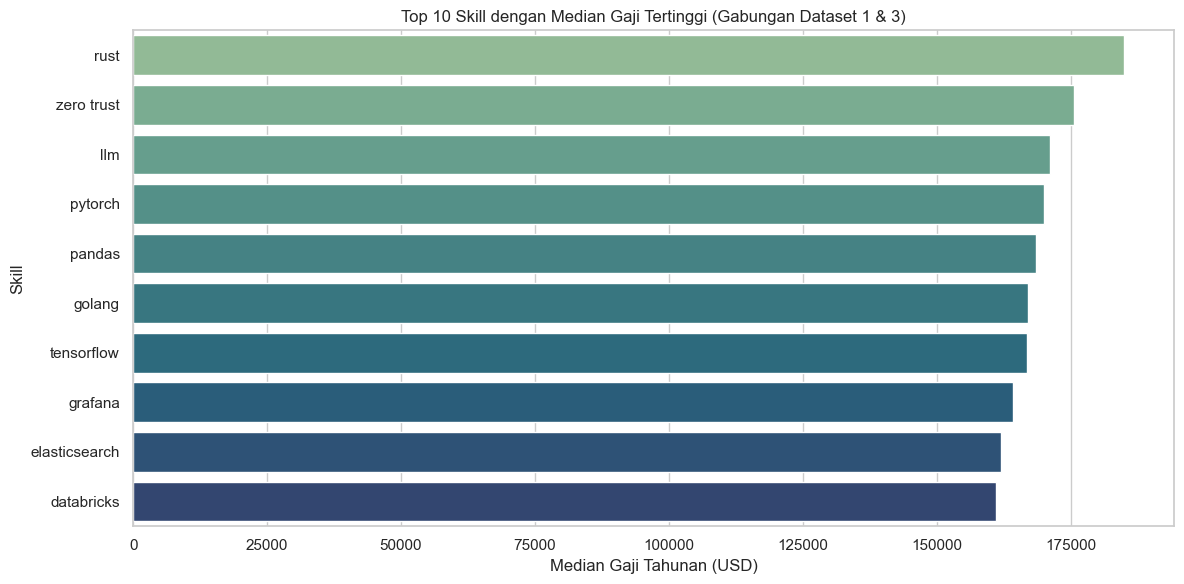

In [130]:
sns.set(style='whitegrid', palette='muted')

# Kita samain kolom gajinya dulu
first_df['salary'] = first_df['normalized_salary']
third_df['salary'] = third_df['med_salary']

first_skill_cols = [col for col in first_df.columns if col.startswith('skill_')]
third_skill_cols = [col for col in third_df.columns if col.startswith('skill_')]

skill_salary = []
for col in first_skill_cols:
    skill_name = col.replace('skill_', '').replace('_', ' ')
    subset = first_df[first_df[col] == 1]
    if len(subset) >= 20 and subset['salary'].notna().any():
        skill_salary.append({
            'skill': skill_name,
            'median_salary': subset['salary'].median(),
            'count': len(subset)
        })

for col in third_skill_cols:
    skill_name = col.replace('skill_', '').replace('_', ' ')
    subset = third_df[third_df[col] == 1]
    if len(subset) >= 20 and subset['salary'].notna().any():
        skill_salary.append({
            'skill': skill_name,
            'median_salary': subset['salary'].median(),
            'count': len(subset)
        })

skill_salary_df = (
    pd.DataFrame(skill_salary)
      .groupby('skill', as_index=False)
      .agg({'median_salary': 'median', 'count': 'sum'})
      .sort_values(['median_salary', 'count'], ascending=[False, False])
      .head(10)
)

display(skill_salary_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=skill_salary_df, x='median_salary', y='skill', palette='crest')
plt.title('Top 10 Skill dengan Median Gaji Tertinggi (Gabungan Dataset 1 & 3)')
plt.xlabel('Median Gaji Tahunan (USD)')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

**Temuan**:

Top 10 skill dengan bayaran tertinggi di remote IT dapat dikelompokkan menjadi tiga kelompok: AI/ML (llm, pytorch, databricks), cloud & modern infrastructure (rust, golang, elasticsearch), serta cybersecurity(zero trust).

**Insight**:

Pasar membayar lebih untuk skill yang berkaitan gelombang transformasi teknologi saat ini: kecerdasan buatan dan cloud-native infrastructure. Dari yang sebelumnya model ML konvensional, sekarang sudah shifting menjadi LLM. Infrastruktur pengembangan pun telah shifting ke modern infrastructure dengan golang & rust. Segi cybersecurity juga mulai ada 'pembaruan' dengan adanya cloudflare zero trust. Bagi job seeker yang hendak mencari gaji lebih tinggi, bisa mulai mempelajari skill dan tools pada daftar, karena skill-skill tersebut masih tergolong 'baru'.

## **2. Bagaimana perbandingan pengalaman kerja dan median gaji di setiap ketagori pekerjaan?**

,formatted_experience_level,salary
1,Director,185000.0
5,Mid-Senior level,109375.0
3,Executive,79250.0
2,Entry level,59000.0
0,Associate,58750.0
4,Internship,44850.0


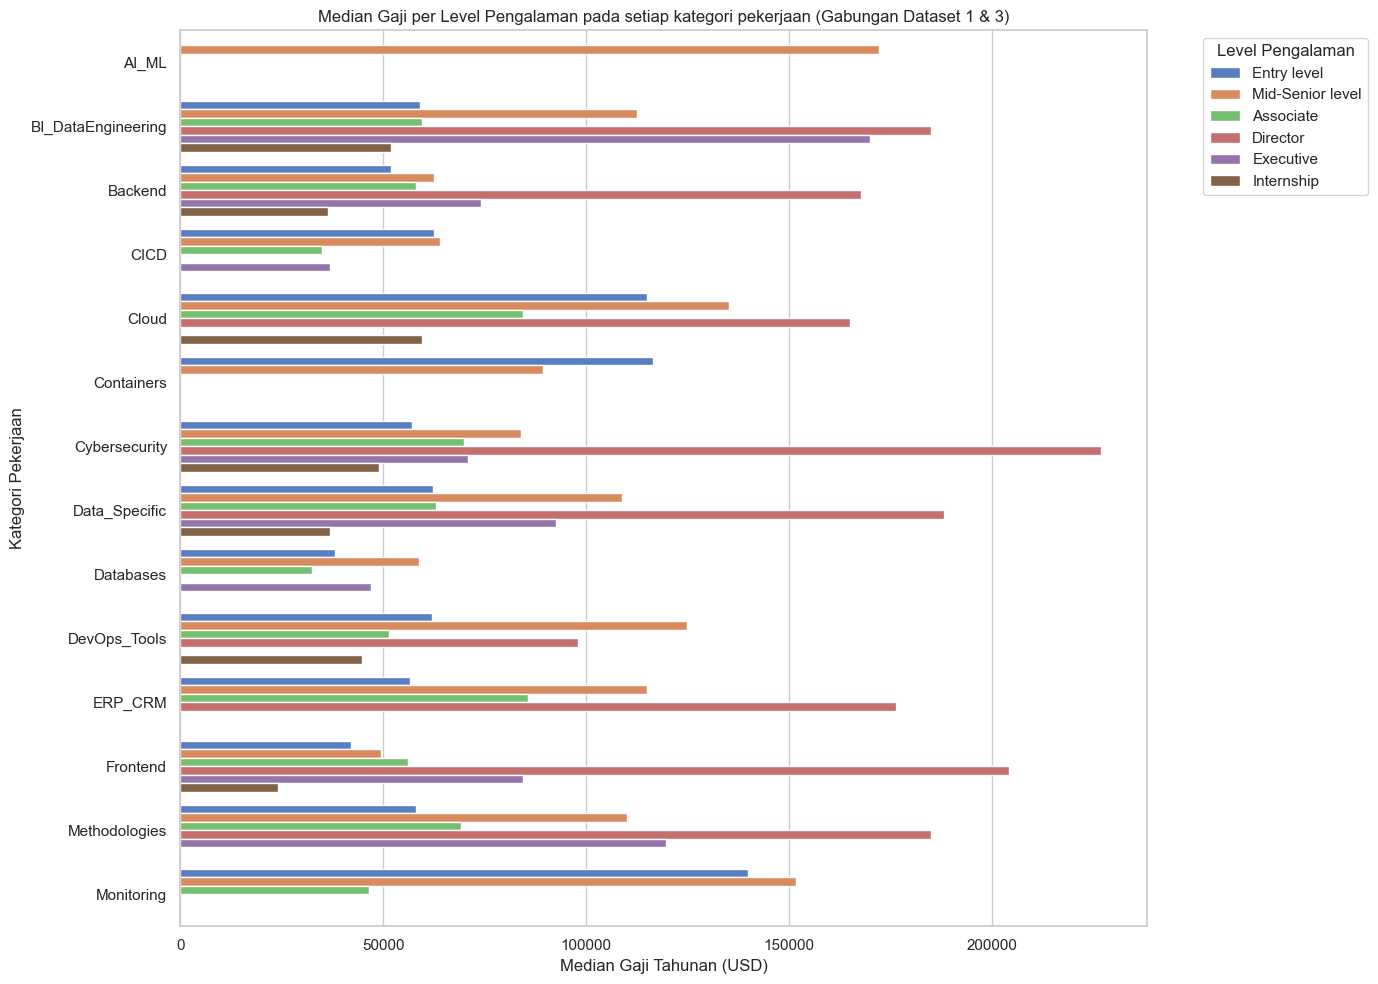

In [131]:
combined_df = pd.concat([
    first_df[['job_category', 'formatted_experience_level', 'salary']],
    third_df[['job_category', 'formatted_experience_level', 'salary']]
], ignore_index=True)

category_order = combined_df['job_category'].value_counts().index
grp = (combined_df[combined_df['job_category'].isin(category_order)]
       .groupby(['job_category', 'formatted_experience_level'])['salary']
       .median()
       .reset_index())

exp_level_salary = grp.groupby(['formatted_experience_level'])['salary'].median().reset_index()
display(exp_level_salary.sort_values('salary', ascending=False))

plt.figure(figsize=(14, 10))
sns.barplot(data=grp, x='salary', y='job_category', hue='formatted_experience_level')
plt.title('Median Gaji per Level Pengalaman pada setiap kategori pekerjaan (Gabungan Dataset 1 & 3)')
plt.xlabel('Median Gaji Tahunan (USD)')
plt.ylabel('Kategori Pekerjaan')
plt.legend(title='Level Pengalaman', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Temuan**:

Di seluruh kategori pekerjaan, terdapat pola yang konsisten: semakin tinggi level jabatan, semakin besar median gaji yang ditawarkan. Level Director mencatatkan median gaji tertinggi di hampir semua kategori.

**Insight**:

Korelasi antara seniority dan kompensasi berlaku universal di industri remote IT. Tidak ada kategori yang menjadi pengecualian, artinya investasi jangka panjang pada depth karir di satu bidang tetap menjadi jalur paling predictable menuju peningkatan penghasilan, dibanding loncat-loncat antar domain.

## **3. Apakah jumlah skill berbanding lurus dengan gaji?**

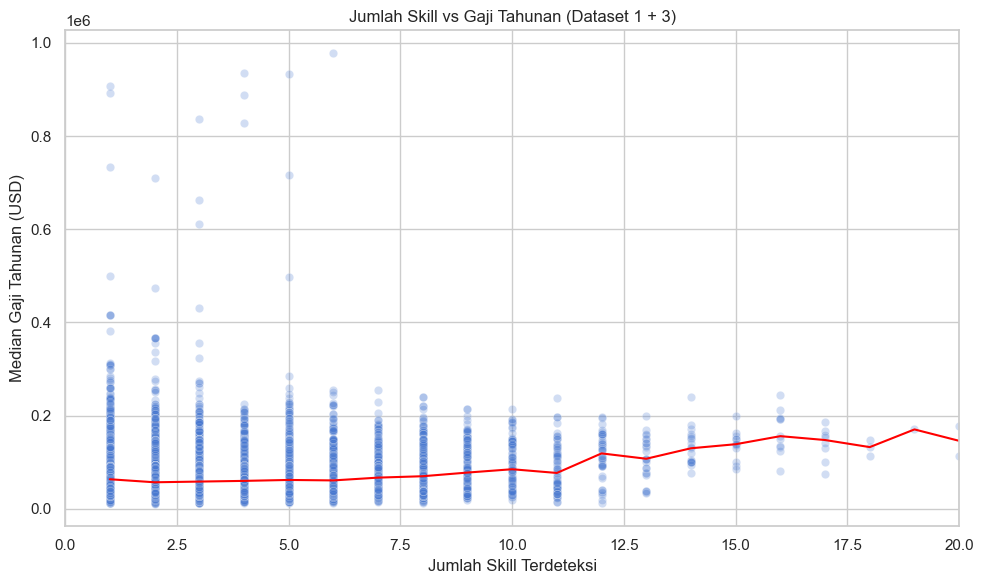

Korelasi jumlah skill dengan gaji: 0.068


In [132]:
skills_vs_med_salary = pd.concat([
    first_df[['extracted_skills_count', 'salary']],
    third_df[['extracted_skills_count', 'salary']]
], ignore_index=True)

median_by_count = skills_vs_med_salary.groupby('extracted_skills_count')['salary'].median().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=skills_vs_med_salary, x='extracted_skills_count', y='salary', alpha=0.25)
sns.lineplot(data=median_by_count, x='extracted_skills_count', y='salary', color='red')
plt.title('Jumlah Skill vs Gaji Tahunan (Dataset 1 + 3)')
plt.xlabel('Jumlah Skill Terdeteksi')
plt.ylabel('Median Gaji Tahunan (USD)')

plt.xlim(0, 20) 

plt.tight_layout()
plt.show()

corr_val = skills_vs_med_salary[['extracted_skills_count', 'salary']].corr().iloc[0, 1]
print(f'Korelasi jumlah skill dengan gaji: {corr_val:.3f}')

**Temuan**:

Nilai korelasi antara jumlah skill dan gaji hanya 0.068, sangat lemah meskipun arahnya positif.


**Insight**:

Lebih banyak skill tidak berarti gaji lebih tinggi. Yang lebih berharga kuantitas skill di CV, melainkan relevansi dan kedalaman skill tersebut. Menumpuk skill secara horizontal tanpa depth adalah strategi yang tidak efisien. Bagi job seeker, sebaiknya fokus pada skill yang tepat karena akan lebih menguntungkan daripada mengejar jumlah.

## **4. 10 Skill paling dicari di dunia remote IT saat ini** 

,skill,count
0,aws,974
1,react,893
2,java,800
3,javascript,660
4,agile,613
5,sql,516
6,python,508
7,scrum,342
8,spring,322
9,azure,317


/tmp/ipykernel_144274/2107481627.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=remote_top_10, x='count', y='skill', palette='rocket')


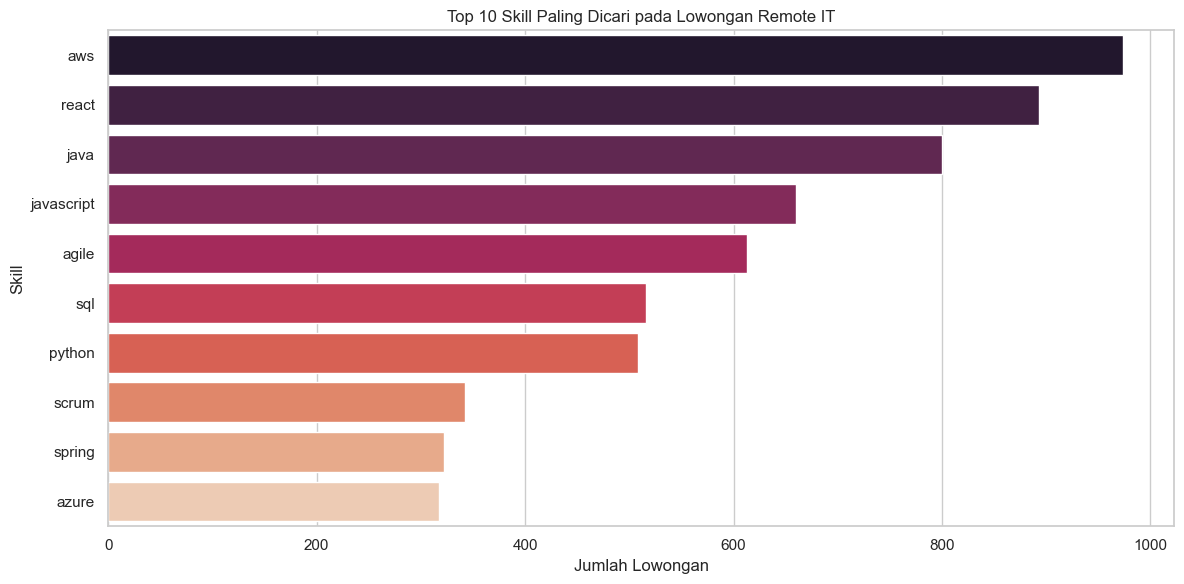

In [133]:
remote_skill_cols = [col for col in second_df.columns if col.startswith('skill_')]
remote_skill_counts = second_df[remote_skill_cols].sum().sort_values(ascending=False).reset_index()
remote_skill_counts.columns = ['skill', 'count']
remote_skill_counts['skill'] = remote_skill_counts['skill'].str.replace('skill_', '', regex=False).str.replace('_', ' ', regex=False)
remote_top_10 = remote_skill_counts.head(10)
display(remote_top_10)

plt.figure(figsize=(12, 6))
sns.barplot(data=remote_top_10, x='count', y='skill', palette='rocket')
plt.title('Top 10 Skill Paling Dicari pada Lowongan Remote IT')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

**Temuan**:

Top skill berdasarkan frekuensi permintaan: AWS, React, Java, JavaScript, Agile, SQL, Python, Scrum, Spring, Azure. Mayoritas skill berakar pada software development konvensional dan metodologi kerja.


**Insight**:

Di tengah hype AI yang masif, permintaan pasar justru masih didominasi skill software development tradisional. Ini adalah sebuah sinyal bagi job seeker bahwa skill konvensional seperti Python, SQL, atau JavaScript belum kehilangan nilai pasarnya. Jika job seeker sudah memiliki fondasi ini, jangan panik dan all in ke AI, skill yang dimiliki masih sangat relevan dan dicari.

### **5. Top 5 skill yang dibutuhkan per kategori pekerjaan**

--- MEMULAI VISUALISASI TOP 5 SKILLS PER ROLE ---


/tmp/ipykernel_144274/3627696831.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=clean_labels, ax=axes[i], palette='viridis')
/tmp/ipykernel_144274/3627696831.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=clean_labels, ax=axes[i], palette='viridis')
/tmp/ipykernel_144274/3627696831.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=clean_labels, ax=axes[i], palette='viridis')
/tmp/ipykernel_144274/3627696831.py:47: FutureWarning: 

Passing `palette` without assigning `hue` i

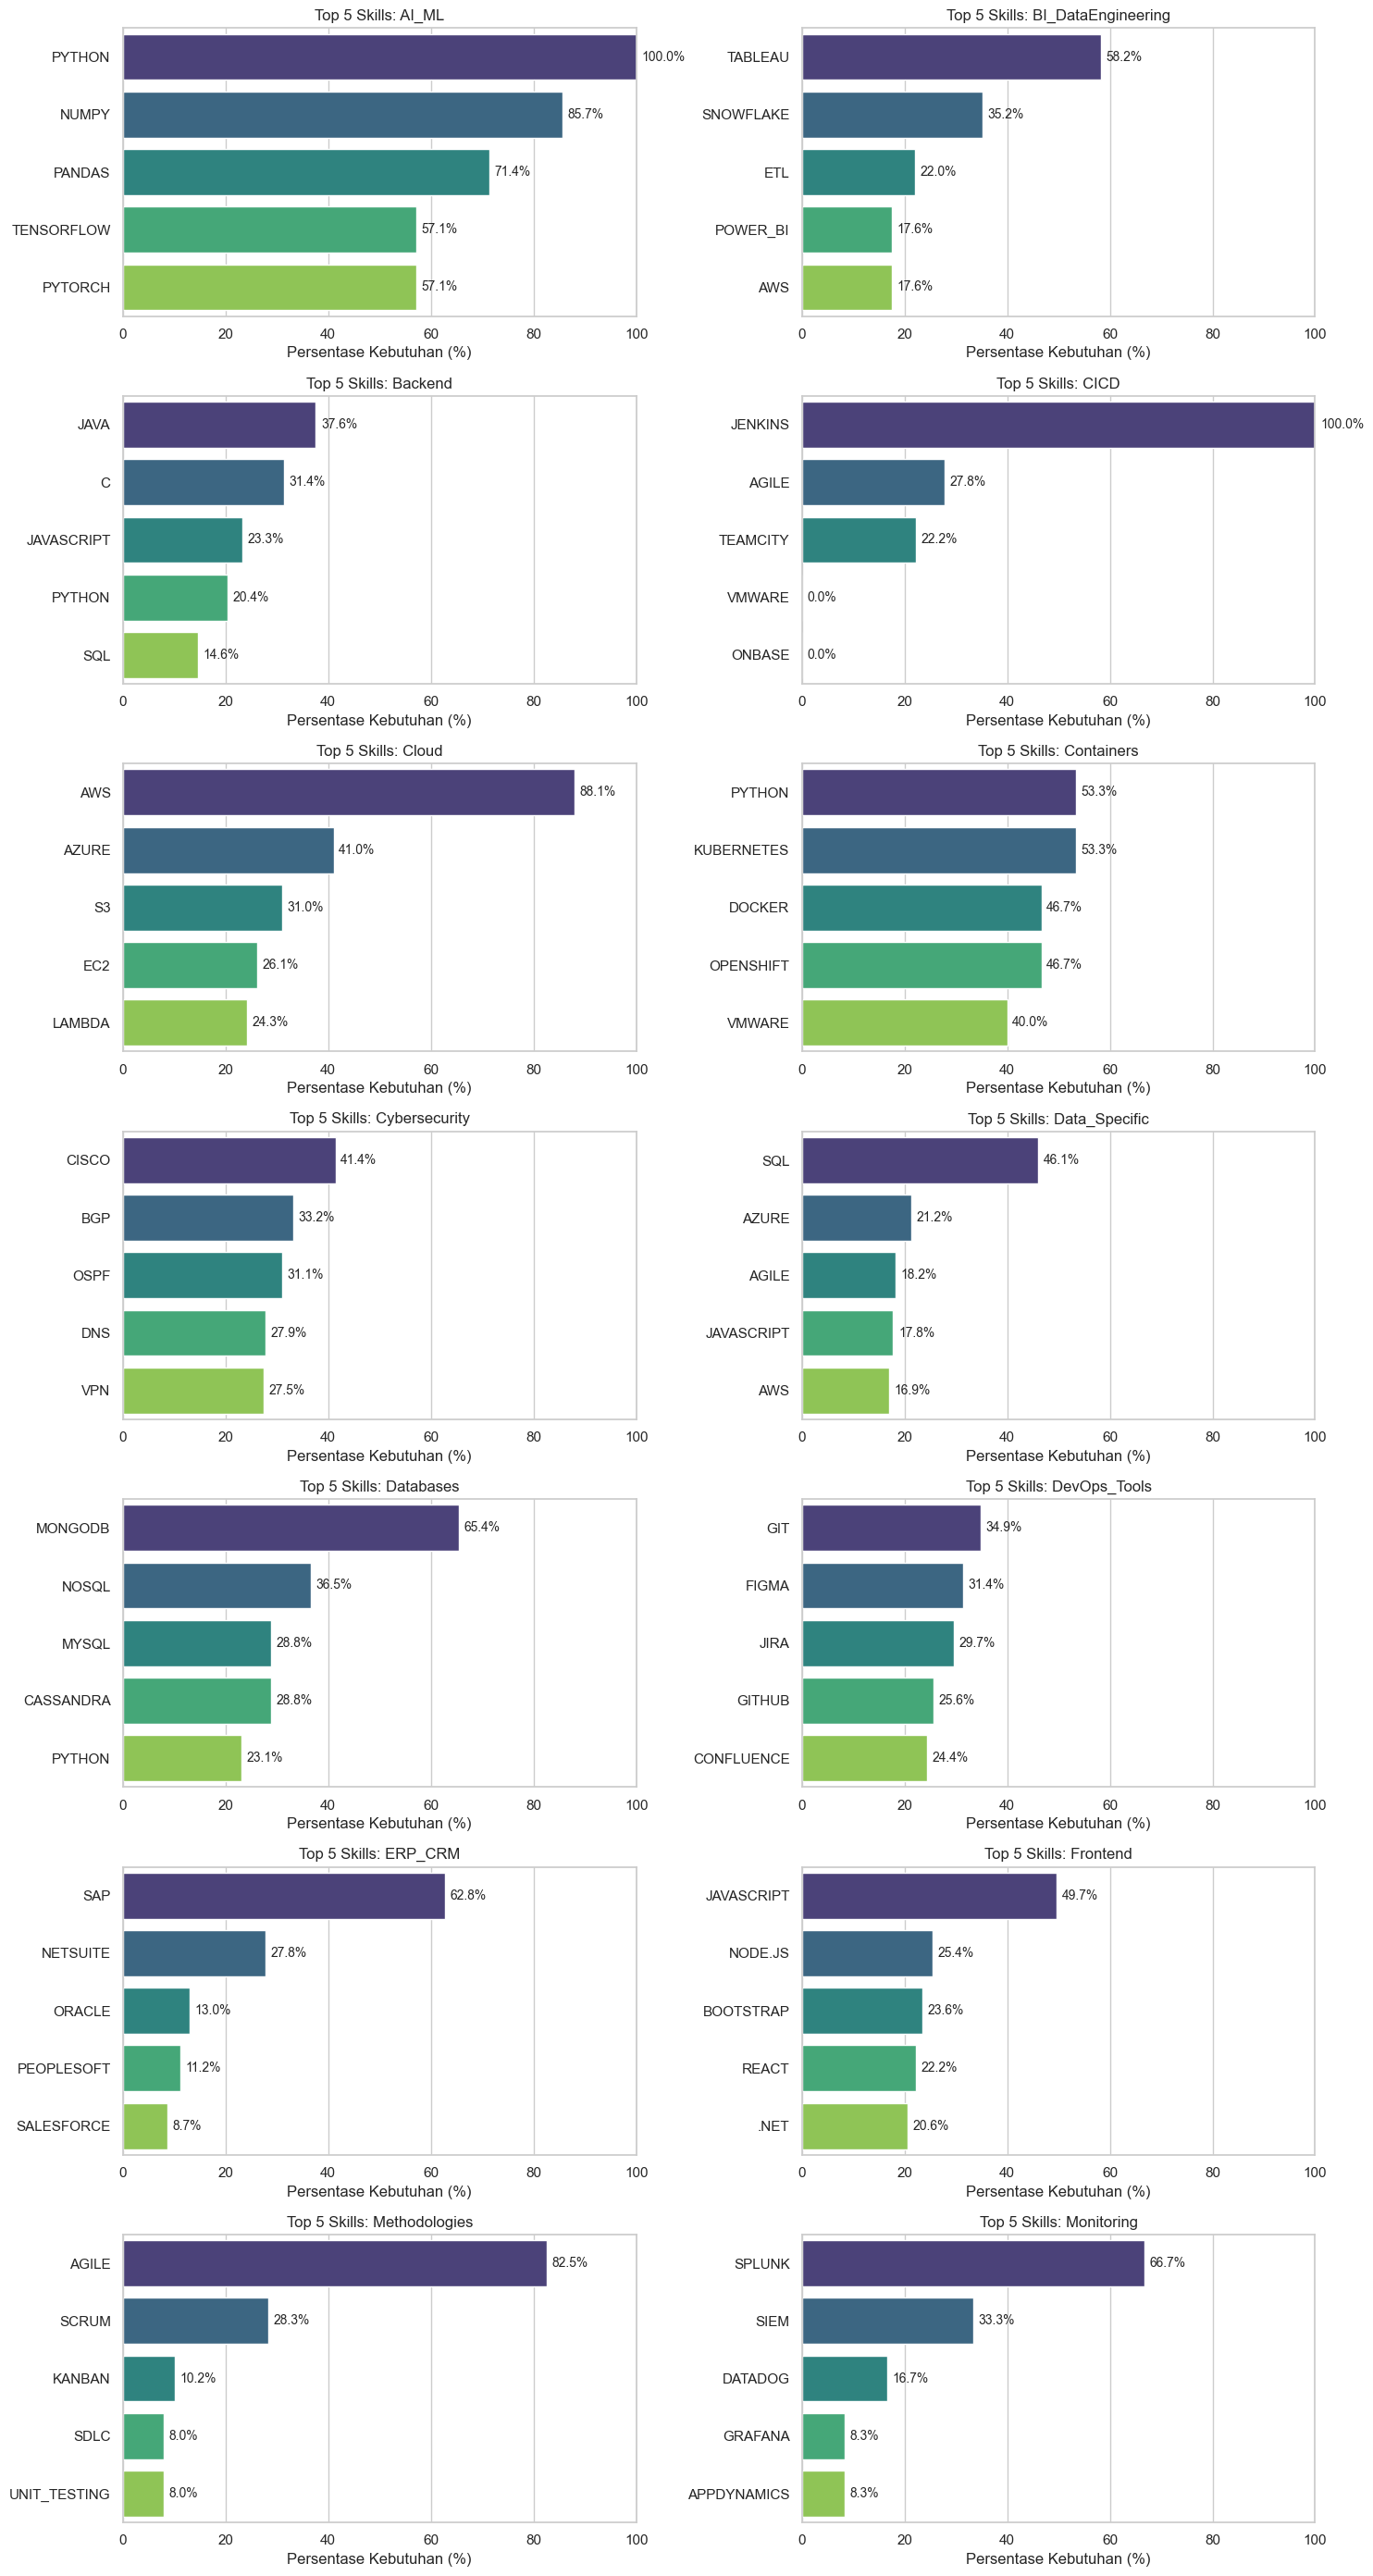

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

skills_cols_1 = [col for col in first_df.columns if col.startswith('skill_')]
skills_cols_2 = [col for col in second_df.columns if col.startswith('skill_')]
skills_cols_3 = [col for col in third_df.columns if col.startswith('skill_')]

skills_cols_all = pd.concat([
    first_df[skills_cols_1],
    second_df[skills_cols_2],
    third_df[skills_cols_3]
], ignore_index=True)

skills_cols_all = skills_cols_all.fillna(0).astype(int)

job_category_1 = [col for col in first_df.columns if col.startswith('job_category')]
job_category_2 = [col for col in second_df.columns if col.startswith('job_category')]
job_category_3 = [col for col in third_df.columns if col.startswith('job_category')]

job_category_all = pd.concat([
    first_df[job_category_1],
    second_df[job_category_2],
    third_df[job_category_3]
], ignore_index=True)

skills_job_combined = pd.concat([job_category_all, skills_cols_all], axis=1)

print("--- MEMULAI VISUALISASI TOP 5 SKILLS PER ROLE ---")

skill_cols_final = [col for col in skills_job_combined.columns if col.startswith('skill_')]

skill_percentage_by_role = skills_job_combined.groupby('job_category')[skill_cols_final].mean() * 100

categories = skill_percentage_by_role.index
num_categories = len(categories)
cols = 2  
rows = math.ceil(num_categories / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() 
for i, category in enumerate(categories):
    top_5 = skill_percentage_by_role.loc[category].sort_values(ascending=False).head(5)
    
    clean_labels = [str(skill).replace('skill_', '').upper() for skill in top_5.index]
    
    sns.barplot(x=top_5.values, y=clean_labels, ax=axes[i], palette='viridis')

    axes[i].set_title(f'Top 5 Skills: {category}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Persentase Kebutuhan (%)')
    axes[i].set_xlim(0, 100) 
    
    for index, value in enumerate(top_5.values):
        axes[i].text(value + 1, index, f'{value:.1f}%', va='center', fontsize=10)

for j in range(num_categories, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Temuan**:

Setiap kategori pekerjaan memiliki skill stack yang distinct dan tidak saling overlap secara signifikan. Tidak ada skill yang mendominasi lintas kategori secara merata.


**Insight**:

IT adalah ekosistem yang highly specialized, setiap domain punya "bahasa" dan toolsnya masing-masing. Bagi para job seeker, pilih kategori target terlebih dahulu, baru bangun skill stack-nya. Berdasarkan data, pendekatan generalis yang berharap satu skill set bisa masuk banyak kategori sekaligus bukanlah strategi yang bagus.

## 6. Berapa rata-rata jumlah skill yang menjadi syarat untuk masing-masing level pengalaman kerja?

,formatted_experience_level,extracted_skills_count
5,Mid-Senior level,4.336712
2,Entry level,3.628004
0,Associate,3.515316
4,Internship,3.008403
1,Director,2.928571
3,Executive,2.925581
6,Other,2.700000


/tmp/ipykernel_144274/572377520.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_skill_by_exp, x='formatted_experience_level', y='extracted_skills_count', palette='mako', order=order_exp)


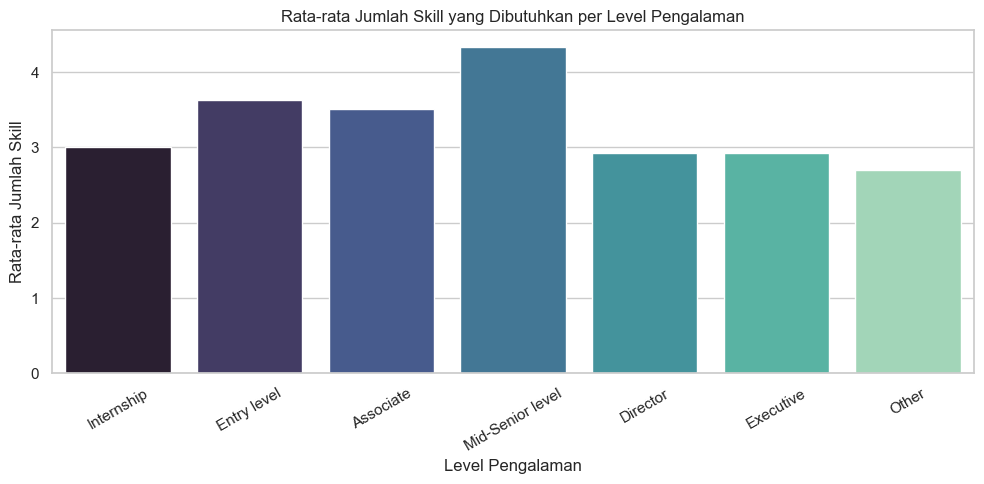

In [135]:
skills_by_exp = pd.concat([
    first_df[['formatted_experience_level', 'extracted_skills_count']],
    second_df[['formatted_experience_level', 'extracted_skills_count']],
    third_df[['formatted_experience_level', 'extracted_skills_count']]
], ignore_index=True)

skills_by_exp = skills_by_exp.dropna(subset=['formatted_experience_level'])

avg_skill_by_exp = (skills_by_exp.groupby('formatted_experience_level')['extracted_skills_count']
                    .mean()
                    .reset_index()
                    .sort_values('extracted_skills_count', ascending=False))
display(avg_skill_by_exp)

order_exp = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive', 'Other']

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_skill_by_exp, x='formatted_experience_level', y='extracted_skills_count', palette='mako', order=order_exp)
plt.title('Rata-rata Jumlah Skill yang Dibutuhkan per Level Pengalaman')
plt.xlabel('Level Pengalaman')
plt.ylabel('Rata-rata Jumlah Skill')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Temuan**:

Rata-rata jumlah skill yang disyaratkan relatif seragam di semua level pengalaman, berkisar antara 3 hingga 5 skill per lowongan.


**Insight**:
Naik level bukan soal mengumpulkan lebih banyak skill, gap antara entry dan senior secara kuantitas skill hampir tidak ada. Yang membedakan level adalah kualitas, kedalaman, dan kemampuan penggunaan skill tersebut. Bagi jobseeker sebaiknya fokus pada mastery, bukan pada menambah daftar skill di CV.

## 7. Lowongan pekerjaan per kategori

/tmp/ipykernel_144274/1202308.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dist_category.head(15), x='count', y='job_category', palette='viridis')


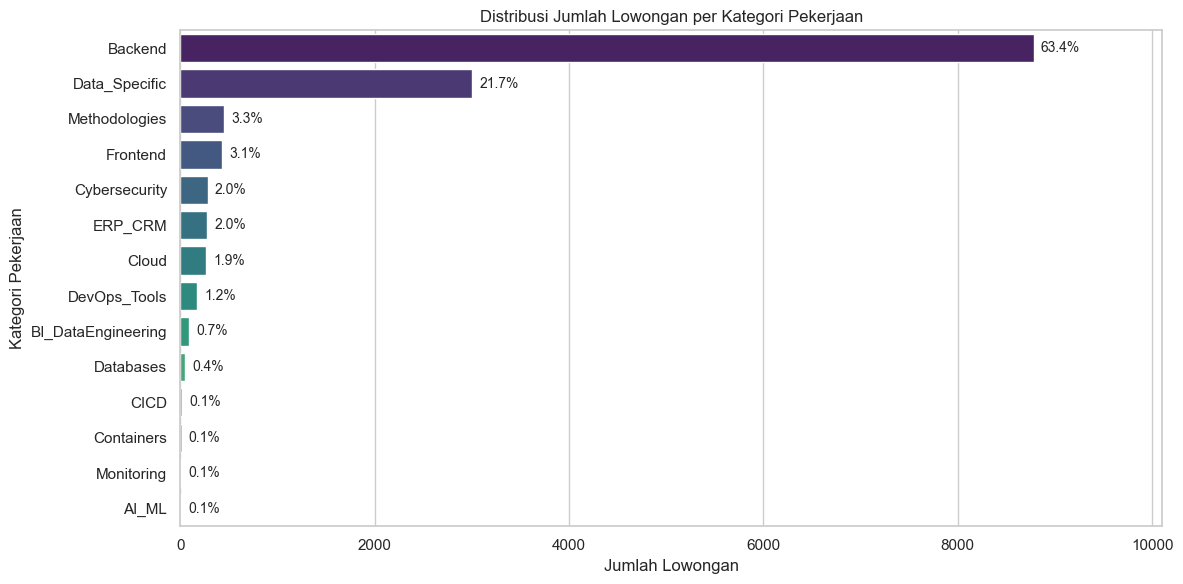

In [136]:
combined_category = pd.concat([
    first_df[['job_category']],
    second_df[['job_category']],
    third_df[['job_category']]
], ignore_index=True)

dist_category = combined_category['job_category'].value_counts().reset_index()
dist_category.columns = ['job_category', 'count']

total_jobs = dist_category['count'].sum()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=dist_category.head(15), x='count', y='job_category', palette='viridis')

plt.title('Distribusi Jumlah Lowongan per Kategori Pekerjaan', fontweight='bold')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Kategori Pekerjaan')

for i, p in enumerate(ax.patches):
    percentage = f'{100 * p.get_width() / total_jobs:.1f}%'
    x = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.annotate(percentage, (x, y), va='center', ha='left', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.xlim(0, dist_category['count'].max() * 1.15)
plt.tight_layout()
plt.show()

**Temuan**:

Distribusi lowongan sangat tidak merata. Backend mendominasi 63.4% dari total lowongan, diikuti Data_Specific sebesar 21.7%. Keduanya menyerap 85.1% dari seluruh pasar. Kategori seperti AI/ML, Containers, Cybersecurity, serta Monitoring hanya <5% dari total lowongan.


**Insight**:
Ada gap yang mencolok antara hype dan realita pasar. AI/ML yang skill-nya masuk top paying hanya memiliki 0.1% share lowongan, ini artinya kompetisinya sangat ketat dengan supply talenta yang terus meningkat. Sebaliknya, Backend dan Data menawarkan volume opportunity yang jauh lebih besar. Bagi job seeker, ini adalah sebuah trade-off. High-paying AI roles itu ada, tapi slot-nya sangat terbatas. Backend tetap menjadi pasar kerja terbesar dan paling accessible berdasarkan data.

## Level pengalaman apa yang paling dicari saat ini?

/tmp/ipykernel_144274/2539430547.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=exp_counts, x='formatted_experience_level', y='count', order=order_exp, palette='cubehelix')


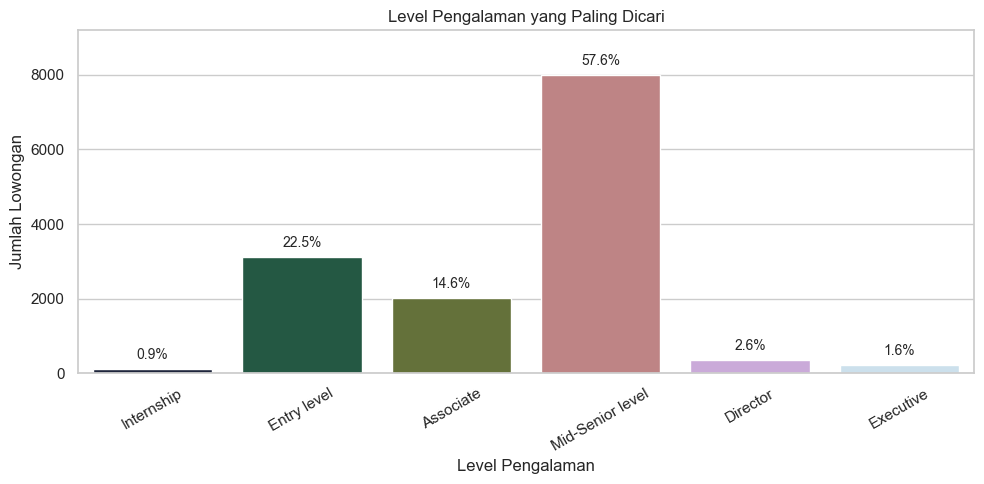

In [137]:
combined_experience = pd.concat([
    first_df[['formatted_experience_level']],
    second_df[['formatted_experience_level']],
    third_df[['formatted_experience_level']]
], ignore_index=True)

exp_counts = combined_experience['formatted_experience_level'].value_counts().reset_index()
exp_counts.columns = ['formatted_experience_level', 'count']

total_exp = exp_counts['count'].sum()

order_exp = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=exp_counts, x='formatted_experience_level', y='count', order=order_exp, palette='cubehelix')

plt.title('Level Pengalaman yang Paling Dicari', fontweight='bold')
plt.xlabel('Level Pengalaman')
plt.ylabel('Jumlah Lowongan')
plt.xticks(rotation=30)

for p in ax.patches:
    if p.get_height() > 0:
        percentage = f'{100 * p.get_height() / total_exp:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), va='bottom', ha='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.ylim(0, exp_counts['count'].max() * 1.15)
plt.tight_layout()
plt.show()

**Temuan**:

Mid-senior level mendominasi permintaan dengan 57.6%, diikuti entry level (22.5%), associate (14.6%), dan lainnya.


**Insight**:

Mayoritas perusahaan bermain aman, mereka mencari kandidat yang sudah bisa langsung produktif tanpa heavy onboarding. Entry level memang ada, tapi job seeker harus bersaing di slot yang lebih sempit dengan pool kandidat yang besar (lihat data sebesar 22.5%). Bagi yang baru memulai, membangun portofolio dan pengalaman nyata secepat mungkin adalah prioritas utama, karena pasar tidak banyak memberikan ruang untuk learning on the job di level awal.

# Filtering untuk ML

In [138]:
os.makedirs('model_data', exist_ok=True)

In [139]:
# Model rekomendasi pekerjaan
job_recommendation_cols = ['job_id', 'title', 'formatted_work_type', 'formatted_experience_level'] + skill_cols

selected_first_df = first_df[job_recommendation_cols]
selected_second_df = second_df[job_recommendation_cols]

job_recommendation_df = pd.concat([selected_first_df, selected_second_df], ignore_index=True)

job_recommendation_df['formatted_work_type'] = job_recommendation_df['formatted_work_type'].fillna('Other')
job_recommendation_df['formatted_experience_level'] = job_recommendation_df['formatted_experience_level'].fillna('Unspecified')

job_recommendation_df = pd.get_dummies(job_recommendation_df, columns=['formatted_work_type'], prefix="work_type", dtype=int)
job_recommendation_df = pd.get_dummies(job_recommendation_df, columns=['formatted_experience_level'], prefix="level", dtype=int)

job_recommendation_df.to_csv('model_data/remote_tech_skills.csv')

In [140]:
first_df_copy = first_df.copy()  
third_df_copy = third_df.copy()

third_df_copy = third_df_copy.rename(columns={"med_salary": "normalized_salary", "name": "title"})
first_df_copy.dropna(subset=['normalized_salary'])

# Model prediksi gaji
salary_prediction_cols = ['title', 'normalized_salary', 'experience_level_num'] + skill_cols

mapping_level = {
    'Unknown': 0,
    'Internship': 1,
    'Entry level': 2,
    'Associate': 3,
    'Mid-Senior level': 4,
    'Director': 5,
    'Executive': 6
}
first_df_copy['experience_level_num'] = first_df_copy['formatted_experience_level'].map(mapping_level)

def map_experience_to_level(years):
    if pd.isna(years):
        return 0
    elif years < 1.0:
        return 1
    elif 1.0 <= years < 3.0:
        return 2
    elif 3.0 <= years < 5.0:
        return 3
    elif 5.0 <= years < 9.0:
        return 4
    elif 9.0 <= years < 13.0:
        return 5
    else:
        return 6
third_df_copy['experience_level_num'] = third_df_copy['experience'].apply(map_experience_to_level)

selected_first_df = first_df_copy[salary_prediction_cols]
selected_third_df = third_df_copy[salary_prediction_cols]

salary_prediction_df = pd.concat([selected_first_df, selected_third_df], ignore_index=True)

salary_prediction_df.to_csv('model_data/combined_data_regression.csv')

## Filtering untuk Dashboard

In [141]:
first_df_copy = first_df.copy()
second_df_copy = second_df.copy()
third_df_copy = third_df.copy()

In [142]:
selected_cols = ["title", "job_category", "formatted_experience_level", "med_salary"] + skill_cols

first_df_copy.rename(columns={"normalized_salary": "med_salary"})

third_df_copy.rename(columns={"name": "title"})

,Unnamed: 0,title,description,experience,salary_range,med_salary,formatted_experience_level,extracted_skills_count,job_category,skill_cfml,...,skill_oracle,skill_helm,skill_sns,skill_microservices,skill_sqs,skill_dynamodb,skill_github_actions,skill_magik,skill_obiee,salary
0,0,.net Web Developer,Job Description Job Description:# Under...,2.0,106k-124k,115000.0,Entry level,7,Backend,0,...,0,0,0,0,0,0,0,0,0,115000.0
2,2,.net Web Developer,Job Description B.A.T. provides a world...,1.0,107k-118k,112500.0,Entry level,4,Backend,0,...,0,0,0,0,0,0,0,0,0,112500.0
3,3,.net Web Developer,Job Description .Net Web Developer (for...,1.0,68k-70k,69000.0,Entry level,7,Backend,0,...,0,0,0,0,0,0,0,0,0,69000.0
4,4,.net Web Developer,Job Description Job Description Develop...,5.0,46k-48k,47000.0,Associate,7,Frontend,0,...,0,0,0,0,0,0,0,0,0,47000.0
5,5,.net Web Developer,Job Description Job Description Good wo...,5.0,53k-93k,73000.0,Associate,6,Backend,0,...,0,0,0,0,0,0,0,0,0,73000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7487,8792,WordPress Web Developer,Job Description Job DescriptionLocation...,2.0,47k-92k,69500.0,Entry level,2,Backend,0,...,0,0,0,0,0,0,0,0,0,69500.0
7488,8793,WordPress Web Developer,Job Description Ability to develop well...,1.0,93k-94k,93500.0,Entry level,6,Data_Specific,0,...,0,0,0,0,0,0,0,0,0,93500.0
7489,8794,Wordpress Web Developer,Job Description Wordpress Web Developer...,1.0,35k-64k,49500.0,Entry level,5,Backend,0,...,0,0,0,0,0,0,0,0,0,49500.0
7490,8795,WordPress Web Developer,Job Description Location:DehradunExperi...,2.0,61k-83k,72000.0,Entry level,2,Backend,0,...,0,0,0,0,0,0,0,0,0,72000.0


In [143]:
# Reindex each dataframe to only have selected_cols, filling missing with NaN
first_df_copy = first_df.reindex(columns=selected_cols, fill_value=pd.NA)
second_df_copy = second_df.reindex(columns=selected_cols, fill_value=pd.NA)
third_df_copy = third_df.reindex(columns=selected_cols, fill_value=pd.NA)

# Combine them vertically
combined_df = pd.concat([first_df_copy, second_df_copy, third_df_copy], ignore_index=True)

In [145]:
os.makedirs('dashboard_data', exist_ok=True)

combined_df.to_csv('dashboard/main.csv', index=False)